# 1. Setup & Environment
- 공간 데이터 및 지도 제작 라이브러리(GeoPandas, MapClassify, Matplotlib) 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 구성

In [1]:
# 1. 라이브러리 로드 및 시각화 환경 설정
from pathlib import Path
import warnings

import geopandas as gpd
import mapclassify
from matplotlib.cm import Greys
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Cartographic Palette (Park et al. 2022 Fig. 4)
- 2개 모형(2SFCA, Gravity) 및 4개년(2021~2024) 분석 대상 정의
- 입출력 경로 및 Fig. 4 전용 팔레트(Greyscale + Hot/Cold 경계선) 설정

In [2]:
# 2. 경로 및 분석 파라미터 정의
BASE_DIR = Path("/mnt/cowork/EV")
BOUNDARY_FP = BASE_DIR / "input/raw/집계구_2016/집계구.shp"
DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)

OUT_FP = DIR_MAPS / "two_model_hotspot_fig4_mw.png"

YEARS = [2021, 2022, 2023, 2024]
MODELS = ["2SFCA", "Gravity"]
MODEL_LABEL = {
    "2SFCA": "Gaussian 2SFCA",
    "Gravity": "Gravity Model"
}

# 카토그래피 스타일 정의 (IJGIS Fig. 4 재현)
K_CLASSES = 15             # Jenks Natural Breaks 구간 수
BORDER_COLOR = "#c9c2ae"  # 집계구 미세 경계선
HOT_LINE = "#d73027"      # Hot Spot 경계선 (Crimson Red)
COLD_LINE = "#2166ac"     # Cold Spot 경계선 (Navy Blue)
TEXT_COLOR = "#222222"    # 텍스트 색상
MUTED_COLOR = "#666666"   # 부제 색상

print(f">> 시각화 구성: {len(MODELS)}개 모형 x {len(YEARS)}개년 = 총 {len(MODELS)*len(YEARS)}개 패널")
print(f">> 출력 대상 파일: {OUT_FP.name}")

>> 시각화 구성: 2개 모형 x 4개년 = 총 8개 패널
>> 출력 대상 파일: two_model_hotspot_fig4_mw.png


# 3. Data Loaders & Model Score Path Resolver
- 서울시 14,979개 집계구 폴리곤(EPSG:5179) 로드
- 모형별 점수 파일(`_mw.csv` 우선) 및 Gi* 핫스팟 판정 데이터 로더 구현

In [3]:
# 3. 경계 및 점수 데이터 로더
def load_seoul_boundary(boundary_path: Path) -> gpd.GeoDataFrame:
    """서울시 집계구 폴리곤 로드 및 좌표계 설정"""
    gdf = gpd.read_file(boundary_path)
    gdf = gdf.set_crs(epsg=5179, allow_override=True)
    gdf["TOT_REG_CD"] = gdf["TOT_REG_CD"].astype(str)
    gdf = gdf[gdf["TOT_REG_CD"].str.startswith("11")].copy().reset_index(drop=True)
    return gdf

gdf_seoul = load_seoul_boundary(BOUNDARY_FP)
print(f">> 서울시 집계구 경계 로드 완료: 총 {len(gdf_seoul):,}개 폴리곤")

def resolve_score_path(model: str, year: int) -> Path:
    """모형별 접근성 점수 CSV 경로 탐색 (_mw 우선)"""
    if model == "2SFCA":
        fp_mw = BASE_DIR / f"output/g2sfca_sfast_final_gaussian/g2sfca_score_{year}_week_낮_normal_mw.csv"
        if fp_mw.exists():
            return fp_mw
        return BASE_DIR / f"output/g2sfca_sfast_final_gaussian/g2sfca_score_{year}_week_낮_normal.csv"
    elif model == "Gravity":
        fp_mw = BASE_DIR / f"output/gravity_model_gaussian/gravity_score_{year}_week_낮_normal_mw.csv"
        if fp_mw.exists():
            return fp_mw
        return BASE_DIR / f"output/gravity_model_gaussian/gravity_score_{year}_week_낮_normal.csv"
    return None

def load_model_scores(gdf: gpd.GeoDataFrame, model: str) -> dict:
    """공통 Natural Breaks 계산을 위해 모형별 4개년 점수를 일괄 로드"""
    by_year = {}
    for year in YEARS:
        fp = resolve_score_path(model, year)
        if not fp.exists():
            raise FileNotFoundError(f"점수 파일 누락: {fp}")
        acc = pd.read_csv(fp, dtype={"oa_code": str})
        acc_reindexed = acc.set_index("oa_code").reindex(gdf["TOT_REG_CD"])["accessibility_score"].fillna(0.0)
        by_year[year] = acc_reindexed.values
    return by_year

# Gi* 핫스팟 데이터 로드 (_mw 우선)
fp_hs_mw = BASE_DIR / "output/two_model_hotspot_k30_mw.csv"
fp_hs_orig = BASE_DIR / "output/two_model_hotspot_k30.csv"
fp_hs = fp_hs_mw if fp_hs_mw.exists() else fp_hs_orig
df_hotspot = pd.read_csv(fp_hs, dtype={"oa_code": str})
print(f">> 핫스팟 판정 데이터 로드 완료: {fp_hs.name}")

>> 서울시 집계구 경계 로드 완료: 총 19,153개 폴리곤
>> 핫스팟 판정 데이터 로드 완료: two_model_hotspot_k30_mw.csv


# 4. Multi-Panel Cartographic Grid Generation (Park et al. 2022 Style)
- 모형별 4개년 풀링 점수 기반 고정 Natural Breaks(k=5) 계산
- 그레이스케일 연속 접근성 배경 + Dissolved Gi* Hot/Cold 외곽 경계선 렌더링
- dissolve 직후 부동소수점 오차로 남는 미세 seam(경계선 끊김) 제거용 소버퍼(+1m/-1m) 스냅 적용
- 하단 통합 범례 배치 및 고해상도(300 DPI) 이미지(`two_model_hotspot_fig4_mw.png`) 저장

RUNNING: PARK ET AL. (2022) FIG.4 REPRODUCTION CARTOGRAPHIC PIPELINE
[2SFCA] 4개년 통합 Natural Breaks 구간 (k=15): [6.09567358e-05 9.66063970e-05 1.31640998e-04 1.69391695e-04
 2.10168188e-04 2.53446407e-04 2.99060532e-04 3.48325017e-04
 4.02852538e-04 4.68150850e-04 5.50247546e-04 6.50550117e-04
 7.77886459e-04 9.51033876e-04 1.23526244e-03]
[Gravity] 4개년 통합 Natural Breaks 구간 (k=15): [ 16.16777847  26.44622555  35.90555758  45.79147776  56.03641288
  67.2418521   79.59524311  92.67936952 107.06967194 122.93749836
 140.71110386 163.34772756 191.52372885 230.79202583 315.54664414]


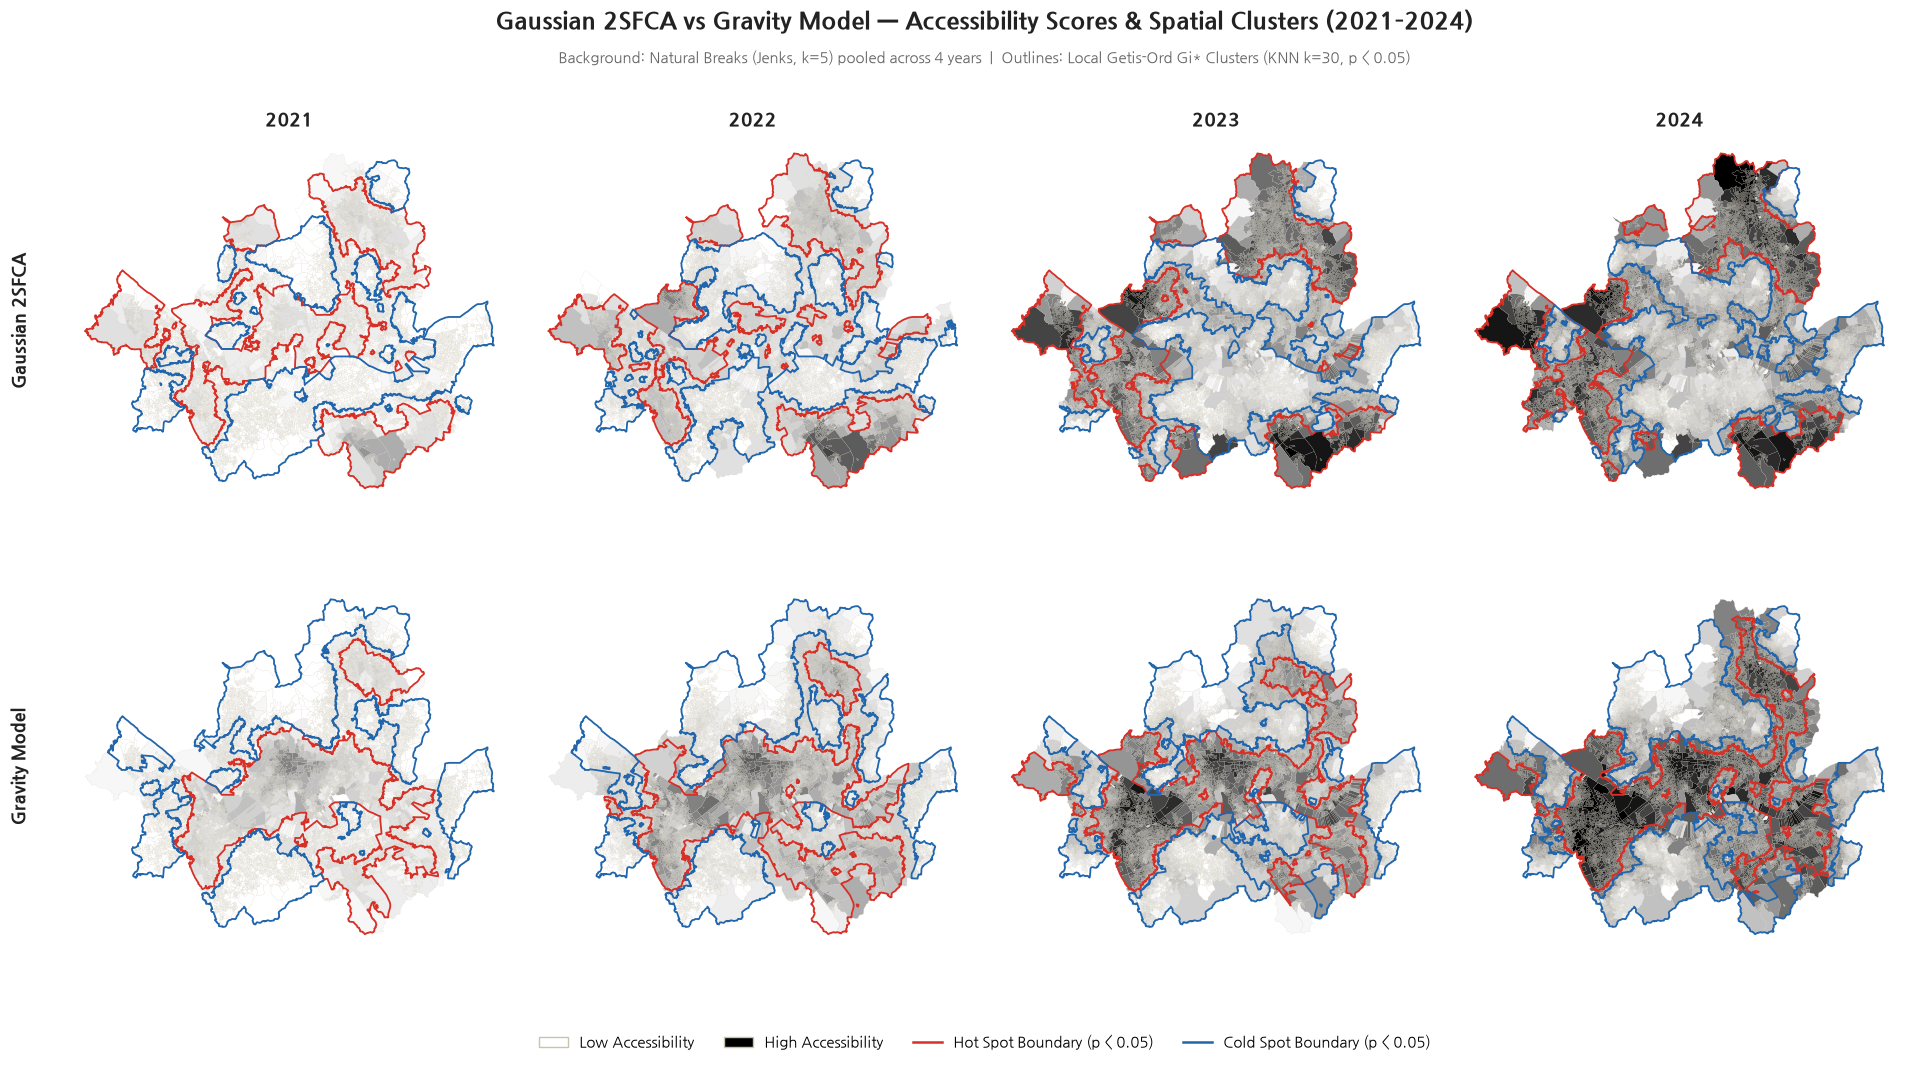


>> IJGIS Fig. 4 스타일 고해상도 비교 지도 저장 완료: /mnt/cowork/EV/output/maps/two_model_hotspot_fig4_mw.png


In [4]:
# 4. Fig. 4 스타일 비교 지도 생성 및 내보내기
print("=" * 85)
print("RUNNING: PARK ET AL. (2022) FIG.4 REPRODUCTION CARTOGRAPHIC PIPELINE")
print("=" * 85)

fig = plt.figure(figsize=(20, 11.2), facecolor="white")
gs = fig.add_gridspec(
    nrows=len(MODELS), 
    ncols=len(YEARS), 
    top=0.87, 
    bottom=0.11, 
    left=0.06, 
    right=0.98, 
    hspace=0.10, 
    wspace=0.03
)

norm = Normalize(vmin=0, vmax=K_CLASSES - 1)

for r, model in enumerate(MODELS):
    # 1. 4개년 데이터 로드 및 점수 풀링(Pooling)
    by_year = load_model_scores(gdf_seoul, model)
    pooled_scores = np.concatenate(list(by_year.values()))

    # 2. 4개년 시계열 공통 Natural Breaks(Jenks, k=5) 구간 산출
    nb = mapclassify.NaturalBreaks(pooled_scores, k=K_CLASSES)
    bins = nb.bins

    print(f"[{model}] 4개년 통합 Natural Breaks 구간 (k={K_CLASSES}): {bins}")

    for c, year in enumerate(YEARS):
        ax = fig.add_subplot(gs[r, c])
        g = gdf_seoul.copy()
        g["score"] = by_year[year]
        
        # 공통 구간 경계 적용 (0 ~ K_CLASSES-1)
        g["cls"] = np.digitize(g["score"], bins[:-1], right=True)
        g["gray_color"] = [Greys(norm(v)) for v in g["cls"]]

        # 배경: 접근성 점수 그레이스케일 폴리곤
        g.plot(ax=ax, color=g["gray_color"], edgecolor=BORDER_COLOR, linewidth=0.08)

        # 오버레이: Gi* 군집 판정 외곽 경계선만 추출하여 렌더링 (면 채우기 없음)
        sub_hs = df_hotspot[(df_hotspot["model"] == model) & (df_hotspot["year"] == year)].set_index("oa_code")
        g["gi_class"] = g["TOT_REG_CD"].map(sub_hs["gi_class"])
        dissolved = g.dissolve(by="gi_class")
        # 인접 집계구 경계가 부동소수점 정밀도 차이로 완전히 안 붙어서 dissolve가
        # 매끈한 폴리곤 대신 미세하게 끊긴 조각(경계선 seam)을 남기는 문제 — 작은 버퍼로 스냅
        dissolved["geometry"] = dissolved.geometry.buffer(1).buffer(-1)

        if "Hot Spot" in dissolved.index:
            dissolved.loc[["Hot Spot"]].boundary.plot(ax=ax, color=HOT_LINE, linewidth=1.3)
        if "Cold Spot" in dissolved.index:
            dissolved.loc[["Cold Spot"]].boundary.plot(ax=ax, color=COLD_LINE, linewidth=1.3)

        ax.set_axis_off()

        # 상단 열 타이틀 (연도)
        if r == 0:
            ax.set_title(f"{year}", fontsize=14, fontweight="bold", color=TEXT_COLOR, pad=8)

        # 좌측 행 라벨 (모형명)
        if c == 0:
            ax.text(
                -0.08, 0.5, MODEL_LABEL[model], 
                transform=ax.transAxes, ha="right", va="center", 
                fontsize=13, fontweight="bold", color=TEXT_COLOR, rotation=90
            )

# 전체 메인 타이틀 및 분석 파라미터 헤더
fig.text(
    0.52, 0.95, 
    "Gaussian 2SFCA vs Gravity Model — Accessibility Scores & Spatial Clusters (2021–2024)", 
    ha="center", fontsize=17, fontweight="bold", color=TEXT_COLOR
)
fig.text(
    0.52, 0.92, 
    "Background: Natural Breaks (Jenks, k=5) pooled across 4 years  |  Outlines: Local Getis-Ord Gi* Clusters (KNN k=30, p < 0.05)", 
    ha="center", fontsize=10.5, color=MUTED_COLOR
)

# 하단 공통 수평 범례 배치
legend_ax = fig.add_axes([0.28, 0.03, 0.48, 0.03])
legend_ax.axis("off")
legend_handles = [
    mpatches.Patch(facecolor=Greys(norm(0)), edgecolor=BORDER_COLOR, label="Low Accessibility"),
    mpatches.Patch(facecolor=Greys(norm(K_CLASSES - 1)), edgecolor=BORDER_COLOR, label="High Accessibility"),
    Line2D([0], [0], color=HOT_LINE, linewidth=1.8, label="Hot Spot Boundary (p < 0.05)"),
    Line2D([0], [0], color=COLD_LINE, linewidth=1.8, label="Cold Spot Boundary (p < 0.05)"),
]
legend_ax.legend(handles=legend_handles, loc="center", ncol=4, frameon=False, fontsize=10.5)

# 고해상도(300 DPI) 이미지 내보내기 및 화면 출력
fig.savefig(OUT_FP, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n>> IJGIS Fig. 4 스타일 고해상도 비교 지도 저장 완료: {OUT_FP}")

# 5. Output Verification
- 생성된 300 DPI 고해상도 이미지 파일의 경로 및 용량(MB) 무결성 확인

In [5]:
# 5. 산출물 파일 상태 확인
if OUT_FP.exists():
    file_size_mb = OUT_FP.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_FP.name}")
    print(f"  절대 경로 : {OUT_FP.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 생성 완료 (Park et al. Fig.4 규격 충족)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_FP}")

  파일명    : two_model_hotspot_fig4_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/two_model_hotspot_fig4_mw.png
  파일 크기 : 7.70 MB
  상태      : 정상 생성 완료 (Park et al. Fig.4 규격 충족)
